# Installation and Imports

In [10]:
import os
path = "../assets/"
os.listdir(path)

['spotify_tracks.csv']

In [11]:
!pip install scikit-learn-extra

In [80]:
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy.stats import skew
import pickle
import ipywidgets as widgets
from IPython.display import display


# Load Data

In [13]:
df = pd.read_csv(path + "/spotify_tracks.csv")
df.head()

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,...,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,track_url,language
0,2r0ROhr7pRN4MXDMT1fEmd,"Leo Das Entry (From ""Leo"")",Anirudh Ravichander,2024,59,https://i.scdn.co/image/ab67616d0000b273ce9c65...,"Leo Das Entry (From ""Leo"")",0.0241,0.753,97297.0,...,8.0,0.1000,-5.994,0.0,0.1030,110.997,4.0,0.459,https://open.spotify.com/track/2r0ROhr7pRN4MXD...,Tamil
1,4I38e6Dg52a2o2a8i5Q5PW,AAO KILLELLE,"Anirudh Ravichander, Pravin Mani, Vaishali Sri...",2024,47,https://i.scdn.co/image/ab67616d0000b273be1b03...,AAO KILLELLE,0.0851,0.780,207369.0,...,10.0,0.0951,-5.674,0.0,0.0952,164.995,3.0,0.821,https://open.spotify.com/track/4I38e6Dg52a2o2a...,Tamil
2,59NoiRhnom3lTeRFaBzOev,Mayakiriye Sirikiriye - Orchestral EDM,"Anirudh Ravichander, Anivee, Alvin Bruno",2024,35,https://i.scdn.co/image/ab67616d0000b27334a1dd...,Mayakiriye Sirikiriye (Orchestral EDM),0.0311,0.457,82551.0,...,2.0,0.0831,-8.937,0.0,0.1530,169.996,4.0,0.598,https://open.spotify.com/track/59NoiRhnom3lTeR...,Tamil
3,5uUqRQd385pvLxC8JX3tXn,Scene Ah Scene Ah - Experimental EDM Mix,"Anirudh Ravichander, Bharath Sankar, Kabilan, ...",2024,24,https://i.scdn.co/image/ab67616d0000b27332e623...,Scene Ah Scene Ah (Experimental EDM Mix),0.2270,0.718,115831.0,...,7.0,0.1240,-11.104,1.0,0.4450,169.996,4.0,0.362,https://open.spotify.com/track/5uUqRQd385pvLxC...,Tamil
4,1KaBRg2xgNeCljmyxBH1mo,Gundellonaa X I Am A Disco Dancer - Mashup,"Anirudh Ravichander, Benny Dayal, Leon James, ...",2024,22,https://i.scdn.co/image/ab67616d0000b2735a59b6...,Gundellonaa X I Am a Disco Dancer (Mashup),0.0153,0.689,129621.0,...,7.0,0.3450,-9.637,1.0,0.1580,128.961,4.0,0.593,https://open.spotify.com/track/1KaBRg2xgNeCljm...,Tamil


In [14]:
df.columns

Index(['track_id', 'track_name', 'artist_name', 'year', 'popularity',
       'artwork_url', 'album_name', 'acousticness', 'danceability',
       'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness',
       'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence',
       'track_url', 'language'],
      dtype='object')

# Data Cleaning..

In [15]:
len(df)  # Before cleaning..

62317

In [16]:
def clean_data(df):

  # Drop the row having null value..
  df.dropna(inplace = True)

  # Drop rows with same track...
  df = df[~df["track_name"].duplicated()]

  df.reset_index(drop=True, inplace=True)

  return df

df = clean_data(df)

In [17]:
len(df)   # After cleaning..

41521

# Artist as an Feature!

In [19]:
# Extract all the unique Artists..

df["artist_name"] = df["artist_name"].str.lower()

df['artist_list'] = (
    df['artist_name']
      .str.split(',')
      .apply(lambda L: [a.strip() for a in L])
)

artist_list  = list(df['artist_name'].str.split(',').apply(lambda L: [a.strip() for a in L]))
artist_list = [a for sublist in artist_list for a in sublist]
artist_list = list(set(artist_list))
len(artist_list)

7578

In [23]:
def extract_artist_songs(df, artist_name):
  return df[df["artist_list"].apply(lambda lst: artist_name in lst)]

def get_same_artist_songs(df, track_name):

    artist_series = df.loc[df['track_name'] == track_name, 'artist_list']
    if artist_series.empty:
        return pd.DataFrame(columns=df.columns)

    artists = artist_series.iloc[0]

    mask = df['artist_list'].apply(lambda lst: any(a in lst for a in artists))

    result = (
        df[mask]
        .drop_duplicates(subset='track_name')
        .reset_index(drop=True)
    )

    return result

# Exploratory Data Analysis (EDA)

In [24]:
df.columns

Index(['track_id', 'track_name', 'artist_name', 'year', 'popularity',
       'artwork_url', 'album_name', 'acousticness', 'danceability',
       'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness',
       'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence',
       'track_url', 'language', 'artist_list'],
      dtype='object')

In [25]:
# Prepare data for training..

X_df = df[['year', 'popularity', 'acousticness', 'danceability',    # Take only numerical values..
       'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness',
       'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']]

Y_df = df[["track_id"]]

X_df

,year,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,2024,59,0.02410,0.753,97297.0,0.970,0.055300,8.0,0.1000,-5.994,0.0,0.1030,110.997,4.0,0.459
1,2024,47,0.08510,0.780,207369.0,0.793,0.000000,10.0,0.0951,-5.674,0.0,0.0952,164.995,3.0,0.821
2,2024,35,0.03110,0.457,82551.0,0.491,0.000000,2.0,0.0831,-8.937,0.0,0.1530,169.996,4.0,0.598
3,2024,24,0.22700,0.718,115831.0,0.630,0.000727,7.0,0.1240,-11.104,1.0,0.4450,169.996,4.0,0.362
4,2024,22,0.01530,0.689,129621.0,0.748,0.000001,7.0,0.3450,-9.637,1.0,0.1580,128.961,4.0,0.593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41516,2021,30,0.08490,0.877,359718.0,0.469,0.000000,7.0,0.1100,-11.458,1.0,0.3530,100.024,4.0,0.504
41517,2021,30,0.07880,0.833,154364.0,0.689,0.000000,8.0,0.2670,-5.061,1.0,0.0813,110.041,4.0,0.524
41518,2021,18,0.00918,0.842,234000.0,0.765,0.000000,7.0,0.0790,-5.855,1.0,0.1370,122.038,4.0,0.669
41519,2021,1,0.10100,0.682,180807.0,0.861,0.000000,1.0,0.3200,-6.061,1.0,0.2850,74.993,4.0,0.439


In [26]:
X_df.describe()

,year,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,41521.000000,41521.000000,41521.000000,41521.000000,4.152100e+04,41521.000000,41521.000000,41521.000000,41521.000000,41521.000000,41521.000000,41521.000000,41521.000000,41521.000000,41521.000000
mean,2013.314973,16.744732,0.386030,0.583150,2.386200e+05,0.581726,0.188996,5.134318,0.196258,-74.681650,0.581393,0.093281,118.080771,3.838178,0.480051
std,10.337078,18.854716,0.321121,0.195265,1.252236e+05,0.259115,0.340106,3.557902,0.177369,2549.007512,0.494653,0.130155,28.883915,0.535037,0.273958
min,1971.000000,0.000000,-1.000000,-1.000000,5.000000e+03,-1.000000,-1.000000,-1.000000,-1.000000,-100000.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2009.000000,0.000000,0.080600,0.474000,1.833470e+05,0.402000,0.000000,2.000000,0.093600,-11.885000,0.000000,0.037000,95.576000,4.000000,0.260000
50%,2016.000000,9.000000,0.325000,0.620000,2.349470e+05,0.616000,0.000083,5.000000,0.125000,-8.091000,1.000000,0.049500,118.019000,4.000000,0.490000
75%,2021.000000,29.000000,0.671000,0.724000,2.863200e+05,0.796000,0.153000,8.000000,0.243000,-5.721000,1.000000,0.091400,135.882000,4.000000,0.706000
max,2024.000000,93.000000,0.996000,0.986000,4.581483e+06,1.000000,0.999000,11.000000,0.998000,1.233000,1.000000,0.959000,239.970000,5.000000,0.995000


## Feature Distribution

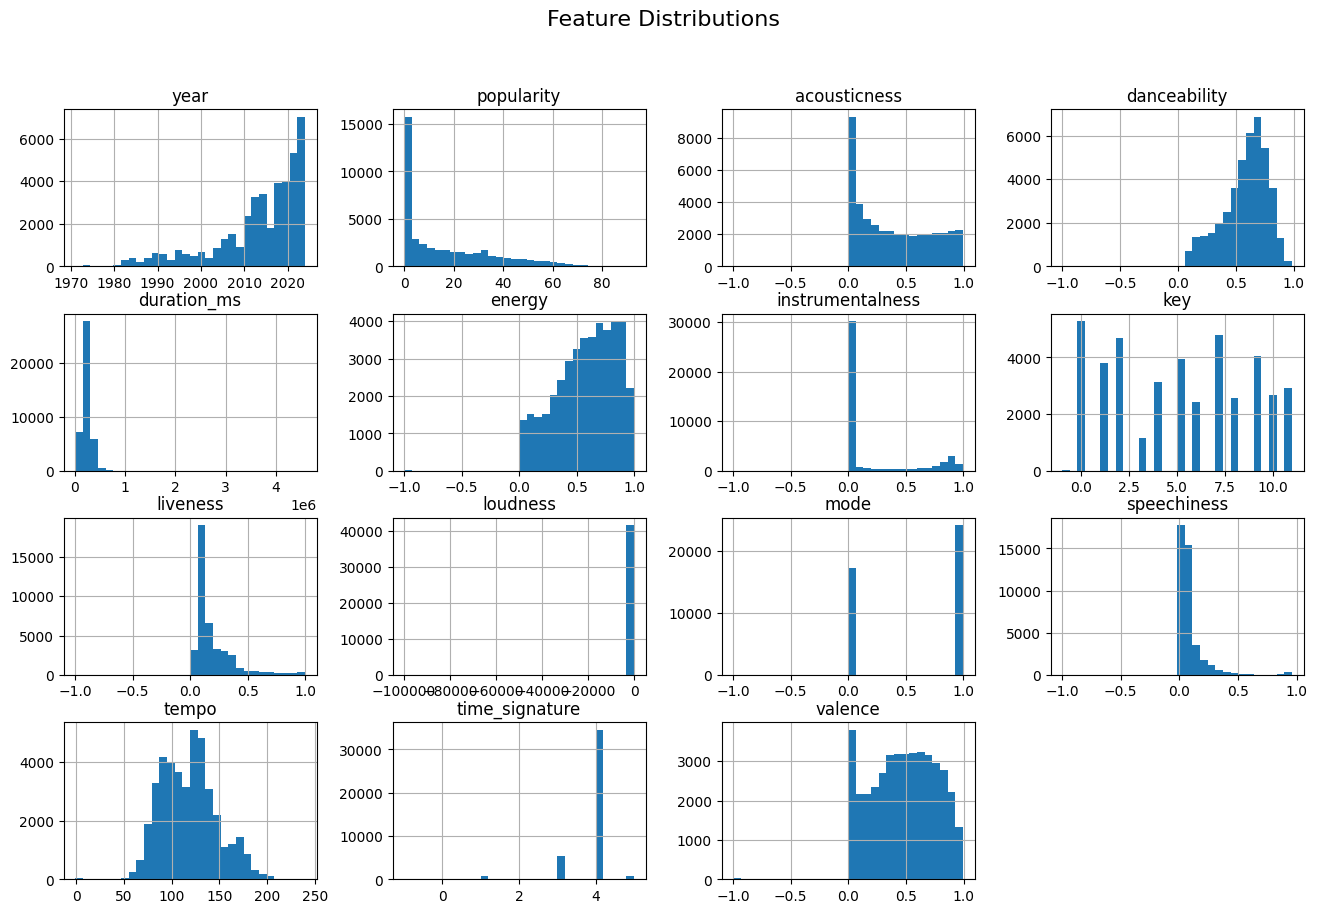

In [27]:
X_df.hist(figsize=(16, 10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

## Boxplot - Check Outliers

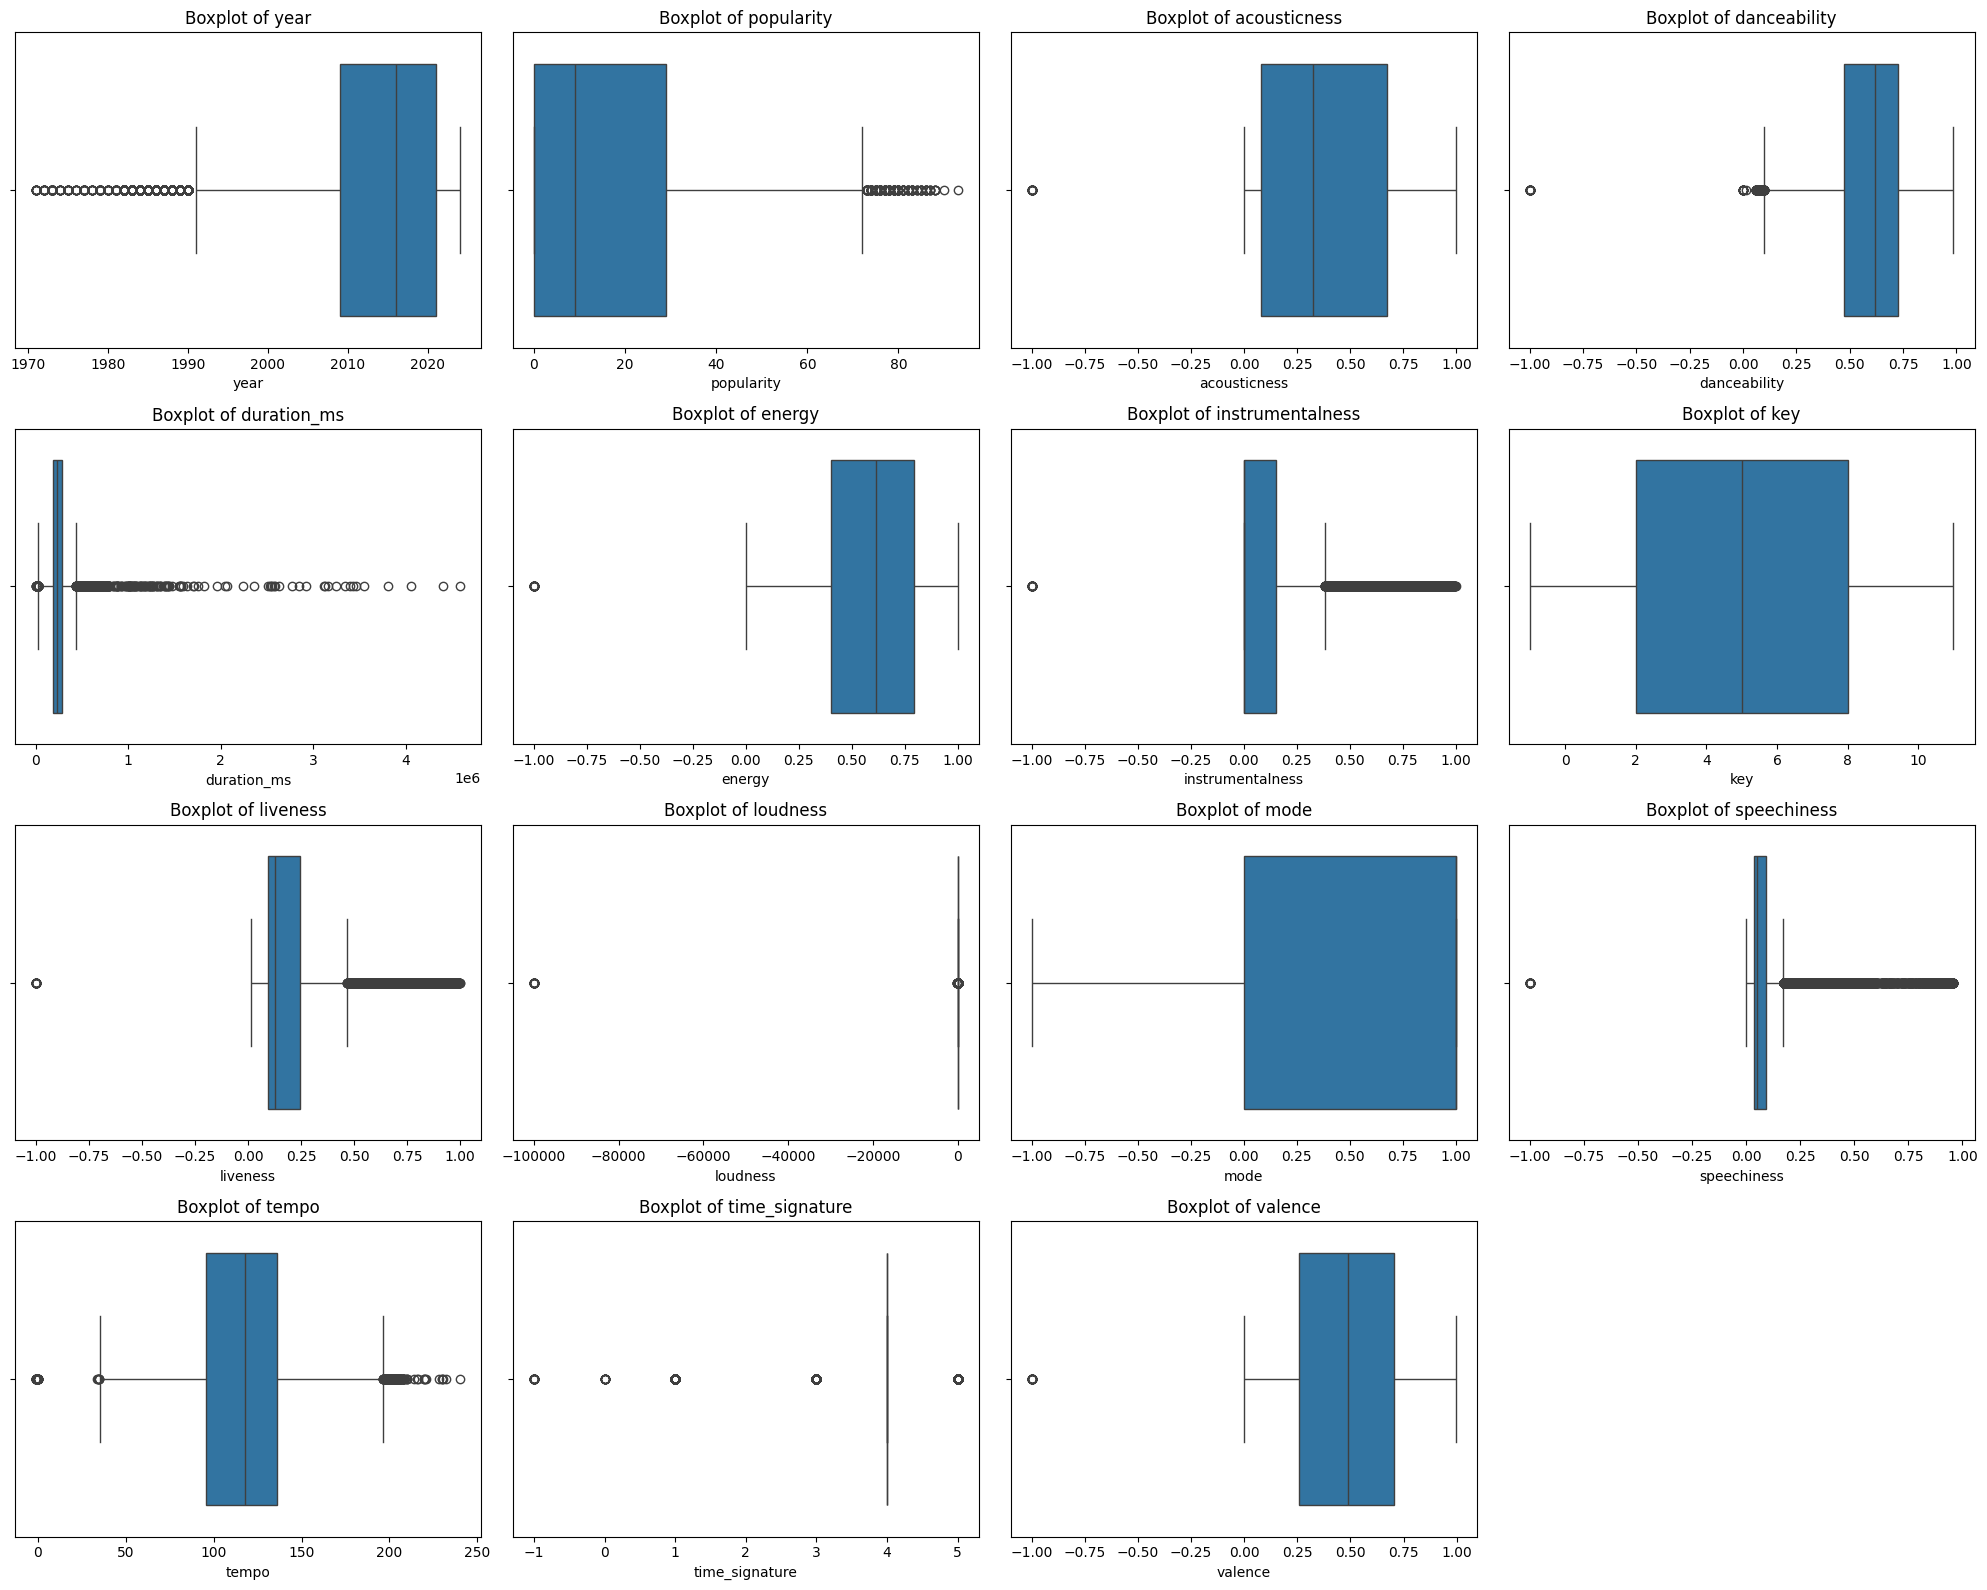

In [28]:
# Define grid size
n_cols = 4
n_rows = math.ceil(len(X_df.columns) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # Flatten in case of single row

# Plot each boxplot
for i, column in enumerate(X_df.columns):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(f"Boxplot of {column}")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Remove outliers

In [35]:
"""

Feature Conditions: :

  1. Year - Outliers are old songs, so we will keep them.
  2. Popularity - Can't be 0.
  3. Acousticness - Can't be smaller than 0.
  4. Danceability - Can't be smaller than 0.
  5. Energy - Can't be smaller than 0.
  6. Instrumentalness - Can't be smaller than 0.
  7. Liveness - Can't be smaller than 0.
  8. Loudness - Can't be smaller than 0. [First repalce the outliers with the mean of song' features 
                              by the same artists, then cap it to postive values.]
  9. Speechiness - Can't be smaller than 0.
  10. Valence - Can't be smaller than 0.
  11. Tempo - Can't be smaller than 0. 
  12. Time_signature - Can't be smaller than 0. -> Alwyas an Integer.
  13. Mode - Can't be smaller than 0. -> 0 or 1 
  14. Duration_ms - Can't be 0. [Needs log transformation, due to high variance.]
  15. Key - Can't be smaller than 0. [Needs to be cyclic, so we will use cosine and sine transformation.]
... and so on...

"""

"\n\nFeature Conditions: :\n\n  1. Year - Outliers are old songs, so we will keep them.\n  2. Popularity - Can't be 0.\n  3. Acousticness - Can't be smaller than 0.\n  4. Danceability - Can't be smaller than 0.\n  5. Energy - Can't be smaller than 0.\n  6. Instrumentalness - Can't be smaller than 0.\n  7. Liveness - Can't be smaller than 0.\n  8. Loudness - Can't be smaller than 0. [First repalce the outliers with the mean of song' features \n                              by the same artists, then cap it to postive values.]\n  9. Speechiness - Can't be smaller than 0.\n  10. Valence - Can't be smaller than 0.\n  11. Tempo - Can't be smaller than 0. \n  12. Time_signature - Can't be smaller than 0. -> Alwyas an Integer.\n  13. Mode - Can't be smaller than 0. -> 0 or 1 \n  14. Duration_ms - Can't be 0.\n  15. Key - Can't be smaller than 0. [Needs to be cyclic, so we will use cosine and sine transformation.]\n... and so on...\n\n"

In [36]:
# Define outlier Conditions for each feature..
is_outlier_cond = {
                    "popularity": lambda x : x == 0,
                   "acousticness": lambda x: x < 0 ,
                   "danceability": lambda x: x <0 , "energy": lambda x: x <0, "instrumentalness": lambda x: x <0,
                   "liveness": lambda x: x <0, "speechiness": lambda x: x<0, "valence": lambda x: x<0,
                    "mode": lambda x: x<0, "loudness": lambda x : x <= -100000,
                    "time_signature": lambda x: x<=0,
                    "tempo": lambda x: x<=0,}

In [33]:
# Replace outliers with the mean of songs' features by the same artists..

def replace_outliers(df, X_df, feature, is_outlier_cond, mode = "mean"):

    """
    For each row where outlier_mask is True on `feature`,
    replace df.at[idx, feature] with:
      — mean of feature over same-artist songs that are NOT outliers, or
      — if that is empty, mean of feature over all songs that are NOT outliers.
    """

    outlier_cond = is_outlier_cond[feature]
    outlier_mask = X_df[feature].apply(outlier_cond)

    # precompute global non-outlier mean
    global_mean = X_df.loc[~outlier_mask, feature].mean()
    global_mode = X_df.loc[~outlier_mask, feature].mode().iloc[0]


    # Remove warning:
    X_df[feature] = X_df[feature].astype(float)


    # iterate only through the outlier rows
    idxs = X_df[outlier_mask].index.tolist()
    for idx in tqdm(idxs):
        track = df.at[idx, 'track_name']

        # all songs by same artist(s)
        peers = get_same_artist_songs(df, track)

        # among those peers, pick only non-outliers
        outlier_mask = peers[feature].apply(outlier_cond)
        peers_non_out = peers.loc[~outlier_mask, feature]

        if mode == "mean":
          if not peers_non_out.empty:
              fill = peers_non_out.mean()
          else:
              fill = global_mean

        elif mode == "max":
          if not peers_non_out.empty:
            fill = peers_non_out.mode().iloc[0]
          else:
            fill = global_mode


        X_df.at[idx, feature] = fill

    return X_df

In [34]:
# Clean each feature...

cleaned_X_df = X_df.copy()
for feature, cond in is_outlier_cond.items():
    tqdm.write("------------------------------------------")
    tqdm.write(f"Cleaning feature: {feature}")


    if feature in ["mode", "time_signature"]:
      cleaned_X_df = replace_outliers(df, cleaned_X_df, feature, is_outlier_cond, mode = "max")
    else:
      cleaned_X_df = replace_outliers(df, cleaned_X_df, feature, is_outlier_cond)
    tqdm.write("\n------------------------------------------")

print("------------------------------------------")
print("Cleaning feature: loudness again!")
cleaned_X_df['loudness'] = cleaned_X_df['loudness'].apply(lambda x: min(x, 0))
print("------------------------------------------")

print("------------------------------------------")
print("Tansforming feature: duration_ms")

# Apply log transformation (add 1 to avoid log(0))
cleaned_X_df['log_duration'] = np.log1p(cleaned_X_df['duration_ms'])
print("------------------------------------------")

------------------------------------------
Cleaning feature: popularity


100%|██████████| 10513/10513 [04:01<00:00, 43.51it/s]



------------------------------------------
------------------------------------------
Cleaning feature: acousticness


100%|██████████| 27/27 [00:00<00:00, 47.23it/s]



------------------------------------------
------------------------------------------
Cleaning feature: danceability


...


------------------------------------------
------------------------------------------
Cleaning feature: time_signature


100%|██████████| 40/40 [00:00<00:00, 47.37it/s]



------------------------------------------
------------------------------------------
Cleaning feature: tempo


100%|██████████| 40/40 [00:00<00:00, 48.71it/s]


------------------------------------------
------------------------------------------
Cleaning feature: loudness again!
------------------------------------------
------------------------------------------
Tansforming feature: duration_ms
------------------------------------------


In [37]:
# Reassignment
X_df = cleaned_X_df

## Correction for Key(s) and Time Signature - Hot Label Encoding

In [38]:
X_df['key_sin'] = np.sin(2 * np.pi * df['key'] / 12)
X_df['key_cos'] = np.cos(2 * np.pi * df['key'] / 12)
X_df.drop(columns='key', inplace=True)

In [39]:
X_df = pd.get_dummies(X_df, columns=['time_signature'], drop_first=False, prefix='ts') # One-hot encoding for time signature

In [41]:
"""One-hot encoded time signature features can dominate other features in downstream analysis
(like PCA or clustering) because their variance is much higher (due to being sparse and binary).
So we will apply MCA-style scaling (centering and scaling) to these columns so that each has 
zero mean and unit variance, reducing their dominance and making the feature space more balanced."""

# Select only the time signature columns
ts_cols = [col for col in X_df.columns if col.startswith("ts")]

# Extract the dummy matrix for the time signature columns
D = X_df[ts_cols].values

# Calculate the mean (proportion) for each column
p = D.mean(axis=0)

# Apply MCA-style scaling (centering and scaling)
Z = (D - p) / np.sqrt(p)

# Scale each column to have unit variance (like StandardScaler)
Z = Z / Z.std(axis=0)

# Create a new DataFrame with scaled values and preserve the original index and column names
Z_df = pd.DataFrame(Z, columns=ts_cols, index=X_df.index)

# Replace the original dummy columns with the scaled ones in the dataframe
X_df[ts_cols] = Z_df

## Draw plots again to check for outliers

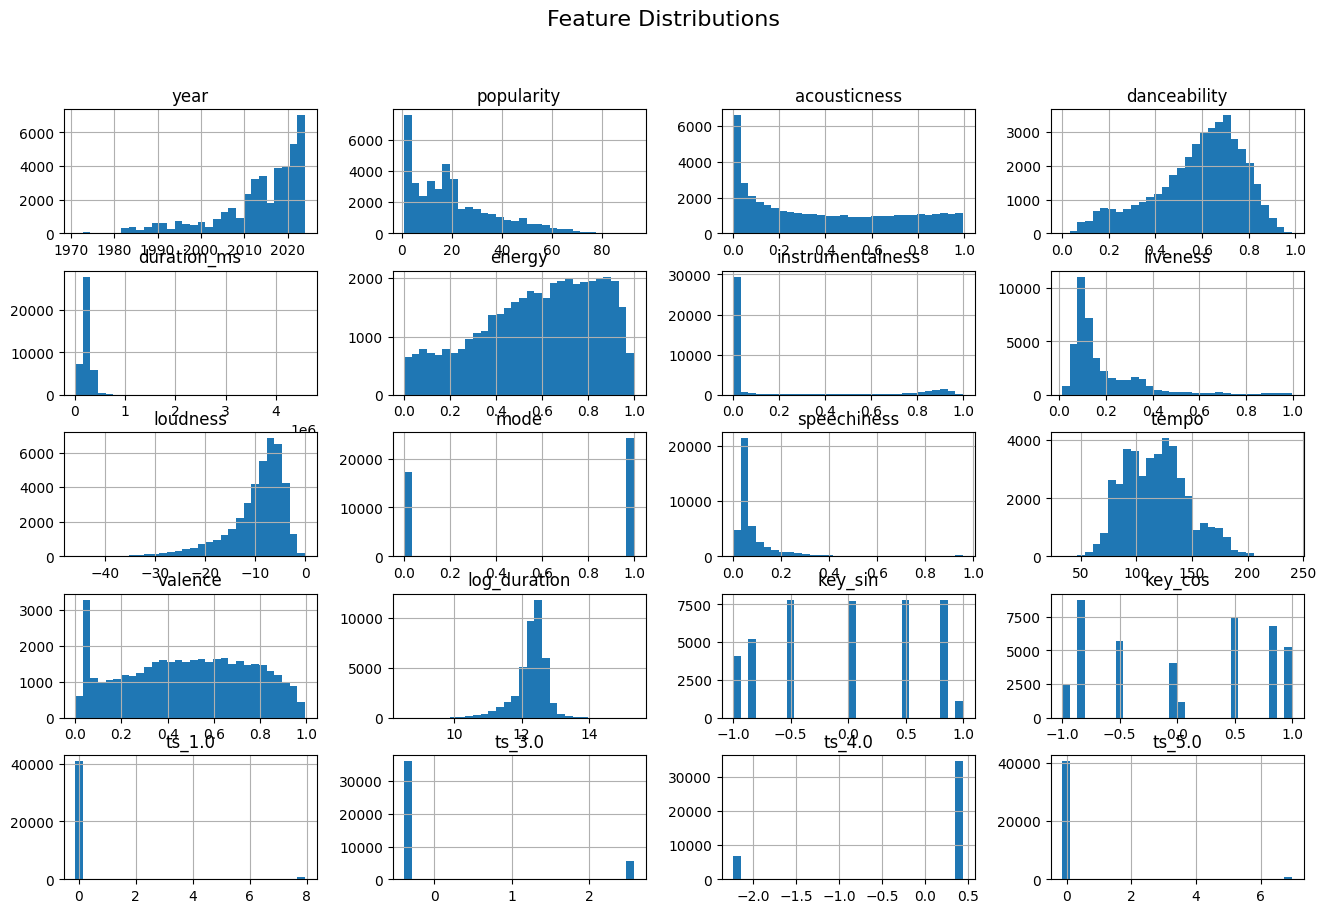

In [42]:
X_df.hist(figsize=(16, 10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

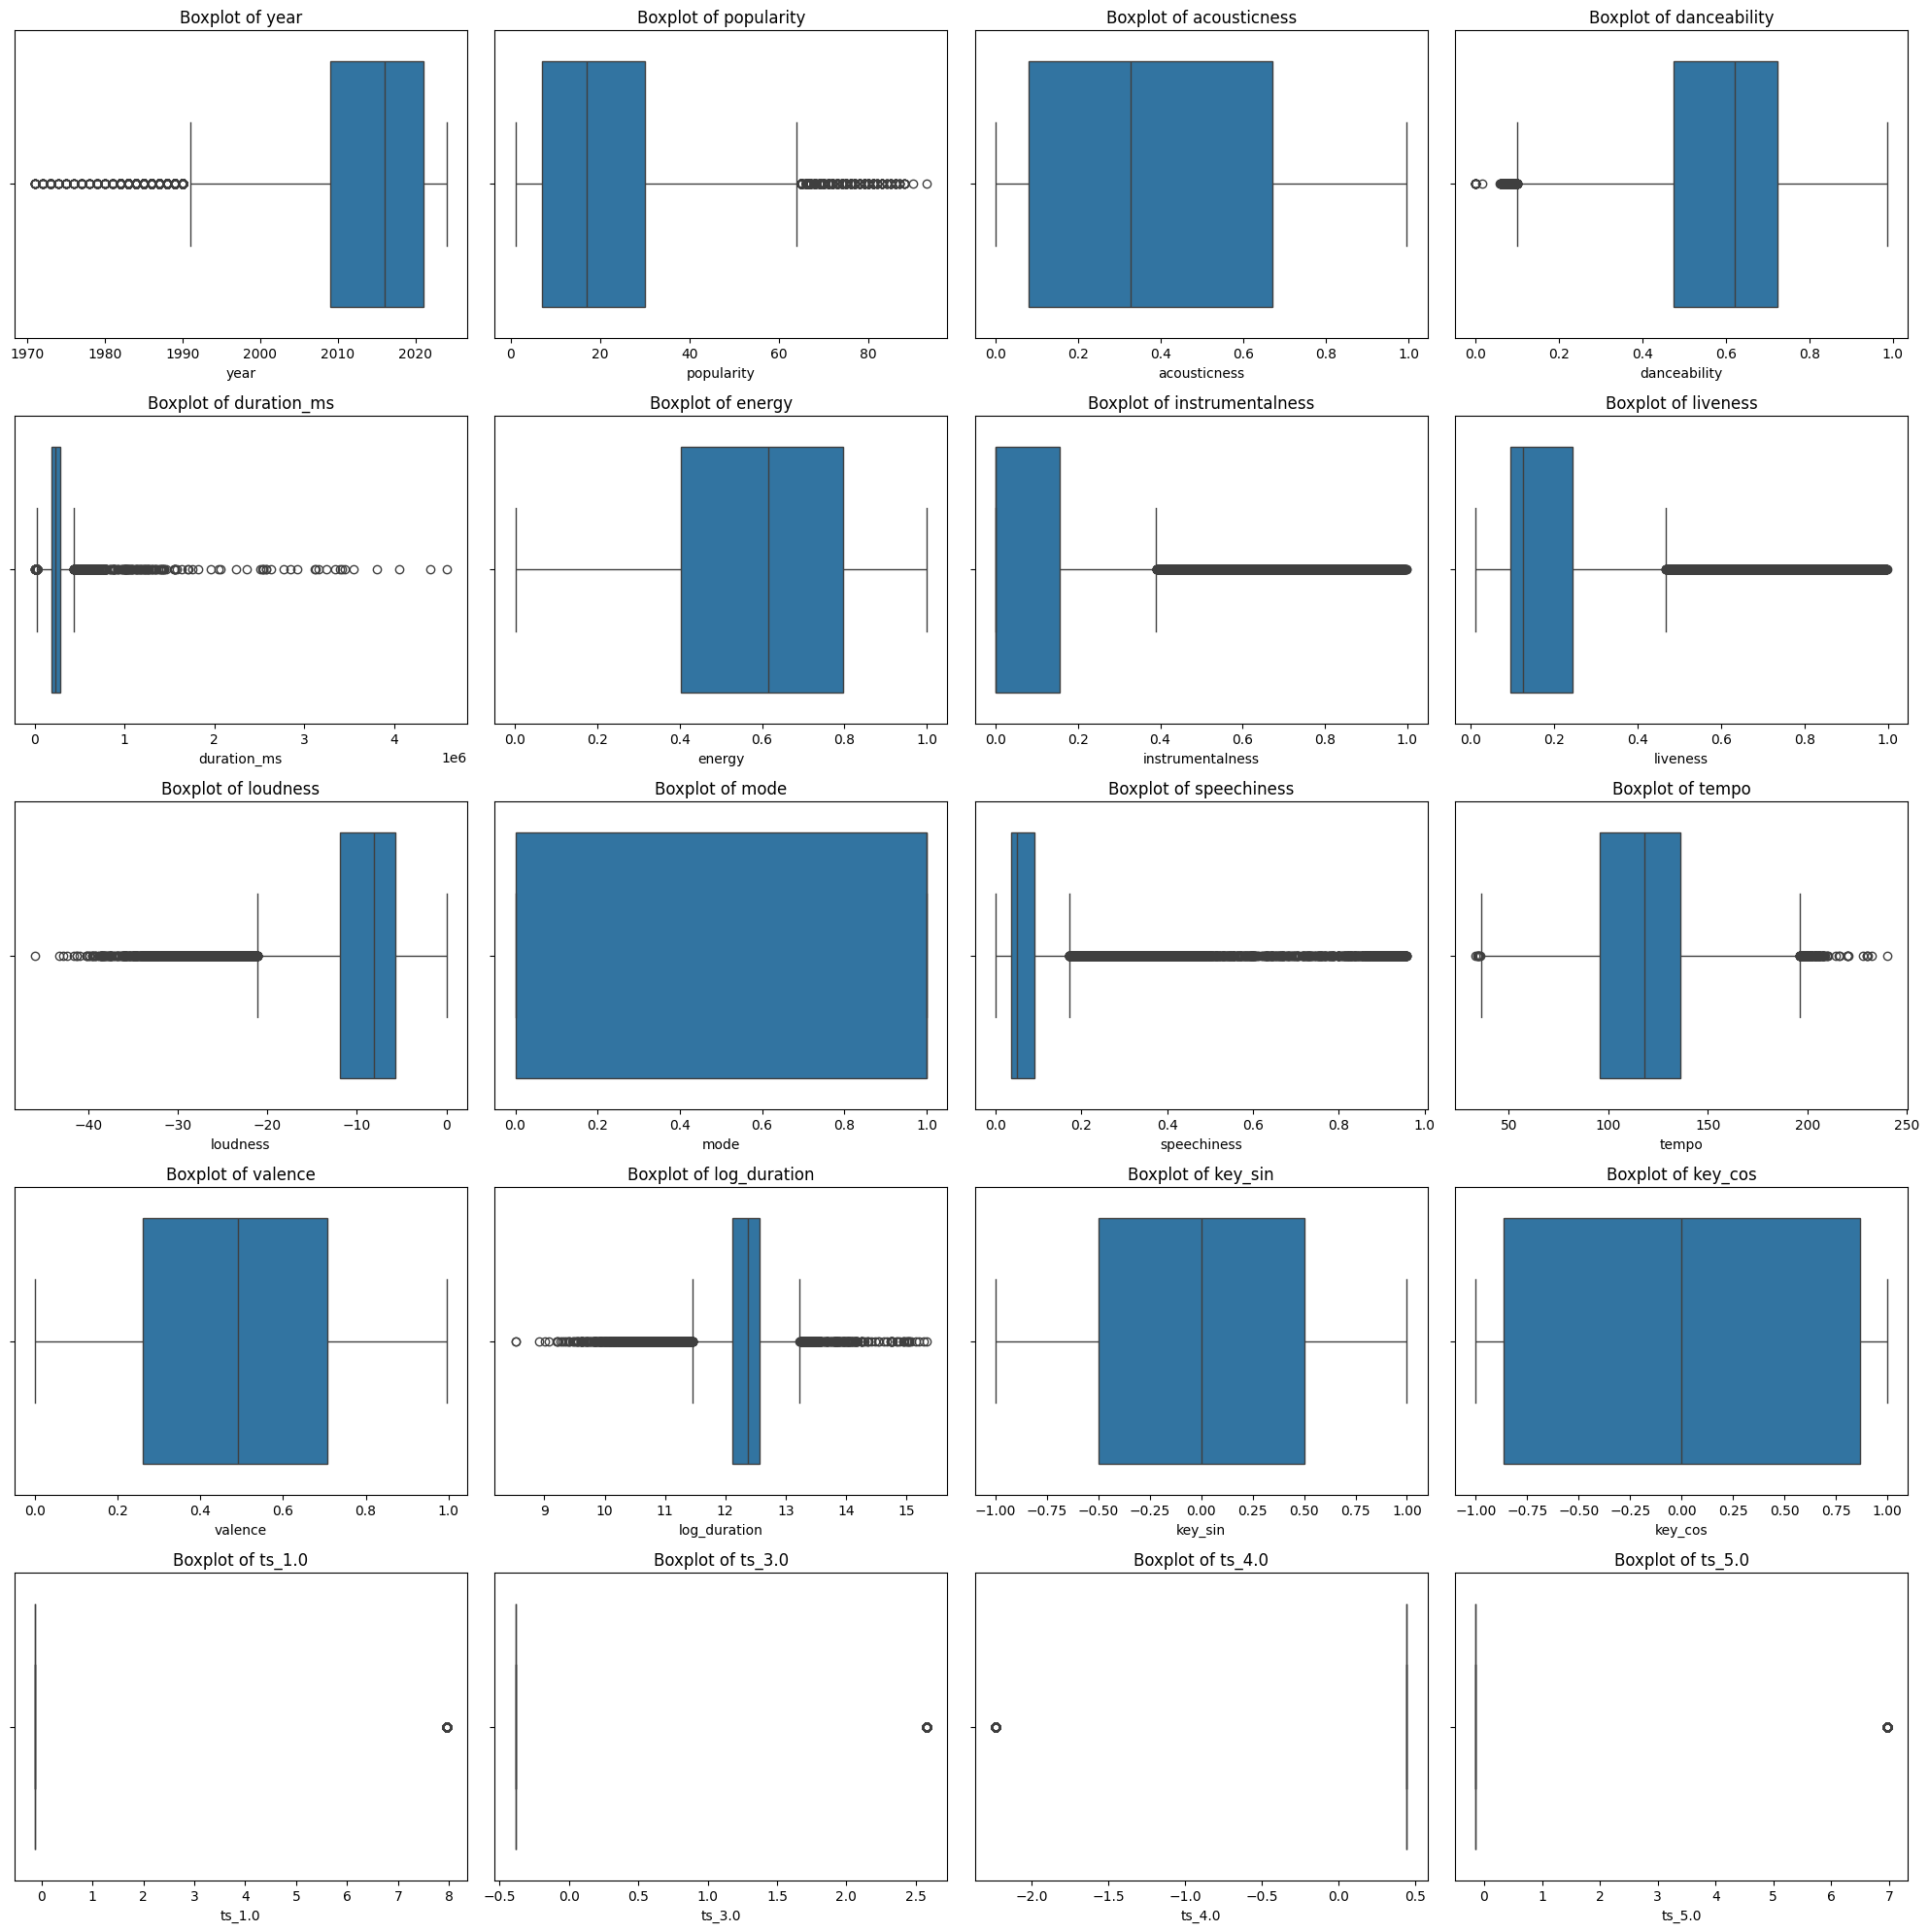

In [43]:
# Define grid size
n_cols = 4
n_rows = math.ceil(len(X_df.columns) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # Flatten in case of single row

# Plot each boxplot
for i, column in enumerate(X_df.columns):
    sns.boxplot(x=X_df[column], ax=axes[i])
    axes[i].set_title(f"Boxplot of {column}")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Heatmap - Check Correlations

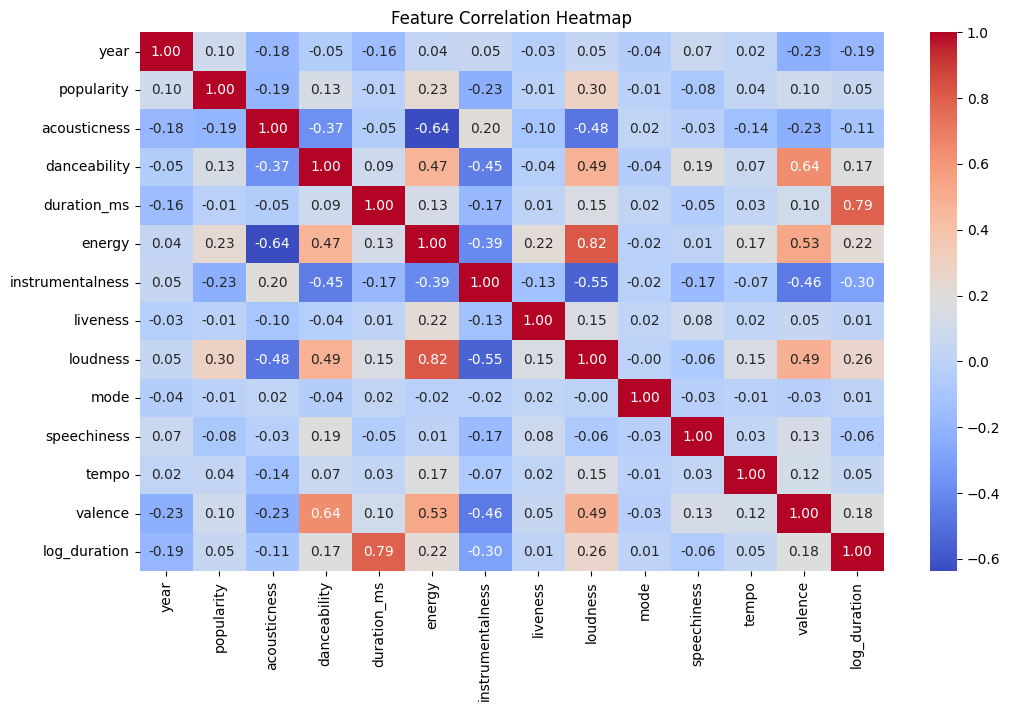

In [44]:
# Compute correlation matrix..

exclude_cols = ['key_cos', 'key_sin']
exclude_cols += [col for col in X_df.columns if col.startswith('ts_')]

# Drop and compute correlation
corr = X_df.drop(columns=exclude_cols).corr()

# Set figure size
plt.figure(figsize=(12, 7))  # Adjust width and height as needed

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


## Scaling the Features

In [45]:
def scale_feature(df, feature, scaling_type='minmax'):
    df = df.copy()
    scaler = None

    if scaling_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaling_type == 'standard':
        scaler = StandardScaler()
    elif scaling_type == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError("Invalid scaling_type. Use 'minmax', 'standard', or 'robust'.")

    df[feature] = scaler.fit_transform(df[[feature]])
    return df

In [46]:
X_df.columns

Index(['year', 'popularity', 'acousticness', 'danceability', 'duration_ms',
       'energy', 'instrumentalness', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'valence', 'log_duration', 'key_sin', 'key_cos',
       'ts_1.0', 'ts_3.0', 'ts_4.0', 'ts_5.0'],
      dtype='object')

In [47]:
features_to_scale = ['year', 'popularity', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'mode', 'speechiness',
       'tempo', 'valence', 'log_duration','key_sin', 'key_cos']

for feature in features_to_scale:
  X_df = scale_feature(X_df, feature, scaling_type='standard')

X_df = X_df.drop(columns= 'duration_ms')

## Language - Hot Label Encoding

In [51]:
X_df["language"] = df["language"]

# One-hot encode the 'language' column
X_df = pd.get_dummies(X_df, columns=['language'],
    prefix='lang',
    prefix_sep='_',
    drop_first=False,
    dtype=int
)


In [52]:
"""Need to apply MCA-style scaling to the language columns as well,
to ensure they have zero mean and unit variance, similar to the time signature columns."""

# Select only the language columns
lang_cols = [col for col in X_df.columns if col.startswith("lang")]

# Extract the dummy matrix for the language columns
D = X_df[lang_cols].values

# Calculate the mean (proportion) for each column
p = D.mean(axis=0)

# Apply MCA-style scaling (centering and scaling)
Z = (D - p) / np.sqrt(p)

# Scale each column to have unit variance (like StandardScaler)
Z = Z / Z.std(axis=0)

# Create a new DataFrame with scaled values and preserve the original index and column names
Z_df = pd.DataFrame(Z, columns=lang_cols, index=X_df.index)

# Replace the original dummy columns with the scaled ones in the dataframe
X_df[lang_cols] = Z_df


# Recommendation System

* Appropriate Scaling
* PCA
* Clustering similar songs
* Finding the nearest neighbour for a song in the same cluster

## Appropriate Scaling: Bias to certain features

In [53]:
X_df.iloc[:, X_df.columns.str.startswith("lang")] = X_df.iloc[:, X_df.columns.str.startswith("lang")]*1.1

In [54]:
X_df.describe()
X_df_copy = X_df.copy() # For backup

,year,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,mode,speechiness,...,ts_3.0,ts_4.0,ts_5.0,lang_English,lang_Hindi,lang_Korean,lang_Malayalam,lang_Tamil,lang_Telugu,lang_Unknown
count,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,...,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04,4.152100e+04
mean,8.241550e-15,-1.629144e-16,-1.659519e-16,9.035586e-17,-5.393971e-16,-2.498476e-17,-1.978246e-16,-1.019926e-16,5.168081e-17,3.833279e-17,...,-2.121994e-17,1.245816e-16,-6.845141e-18,-5.202307e-17,3.422570e-17,-1.916639e-17,-8.214169e-18,1.971401e-16,-1.283464e-17,-2.217826e-16
std,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,...,1.000012e+00,1.000012e+00,1.000012e+00,1.100013e+00,1.100013e+00,1.100013e+00,1.100013e+00,1.100013e+00,1.100013e+00,1.100013e+00
min,-4.093563e+00,-1.166926e+00,-1.212382e+00,-3.056213e+00,-2.275370e+00,-5.604884e-01,-1.059379e+00,-6.275733e+00,-1.181249e+00,-7.391602e-01,...,-3.878417e-01,-2.237264e+00,-1.435210e-01,-7.797431e-01,-3.404693e-01,-4.103820e-01,-7.094543e-02,-5.963710e-01,-8.369727e-02,-5.823229e-01
25%,-4.174318e-01,-8.128804e-01,-9.589524e-01,-5.760574e-01,-7.054425e-01,-5.604884e-01,-5.917967e-01,-3.835496e-01,-1.181249e+00,-4.473417e-01,...,-3.878417e-01,4.469745e-01,-1.435210e-01,-7.797431e-01,-3.404693e-01,-4.103820e-01,-7.094543e-02,-5.963710e-01,-8.369727e-02,-5.823229e-01
50%,2.597503e-01,-2.223925e-01,-1.911309e-01,1.878724e-01,1.303310e-01,-5.602400e-01,-4.120894e-01,2.728299e-01,8.465613e-01,-3.498067e-01,...,-3.878417e-01,4.469745e-01,-1.435210e-01,-7.797431e-01,-3.404693e-01,-4.103820e-01,-7.094543e-02,-5.963710e-01,-8.369727e-02,-5.823229e-01
75%,7.434518e-01,5.442937e-01,8.896461e-01,7.320415e-01,8.333180e-01,-1.002620e-01,2.632440e-01,6.825478e-01,8.465613e-01,-2.023274e-02,...,-3.878417e-01,4.469745e-01,-1.435210e-01,1.551793e+00,-3.404693e-01,-4.103820e-01,-7.094543e-02,-5.963710e-01,-8.369727e-02,-5.823229e-01
max,1.033673e+00,4.261770e+00,1.907769e+00,2.102929e+00,1.630037e+00,2.386730e+00,4.584233e+00,1.672829e+00,8.465613e-01,6.804072e+00,...,2.578372e+00,4.469745e-01,6.967620e+00,1.551793e+00,3.553918e+00,2.948473e+00,1.705536e+01,2.028938e+00,1.445686e+01,2.077885e+00


## Principal Component Analysis (PCA)

In [58]:
# Keep only useful features for PCA..
X_df.drop(columns=['ts_1.0', 'ts_3.0', 'ts_4.0', 'ts_5.0', 'mode', 'year', 'popularity'], inplace=True)
pca = PCA(n_components = 8)
X_pca = pca.fit_transform(X_df)
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.20060276, 0.08863789, 0.078574  , 0.06799414, 0.06144573,
       0.05953905, 0.0594889 , 0.05468357])

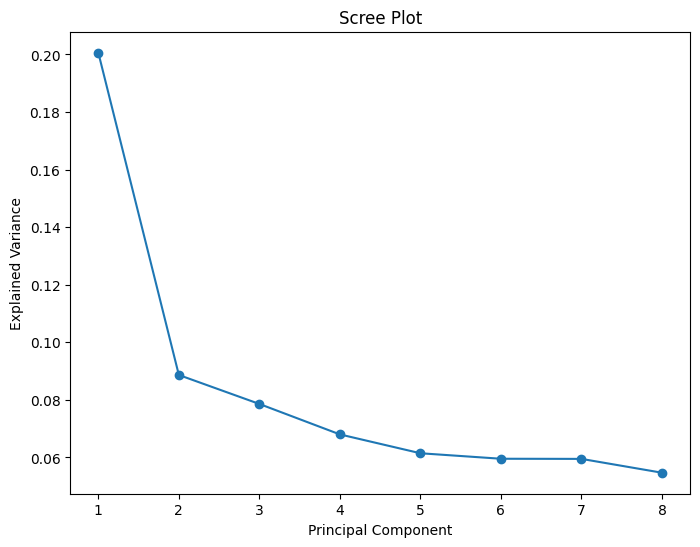

In [59]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.show()

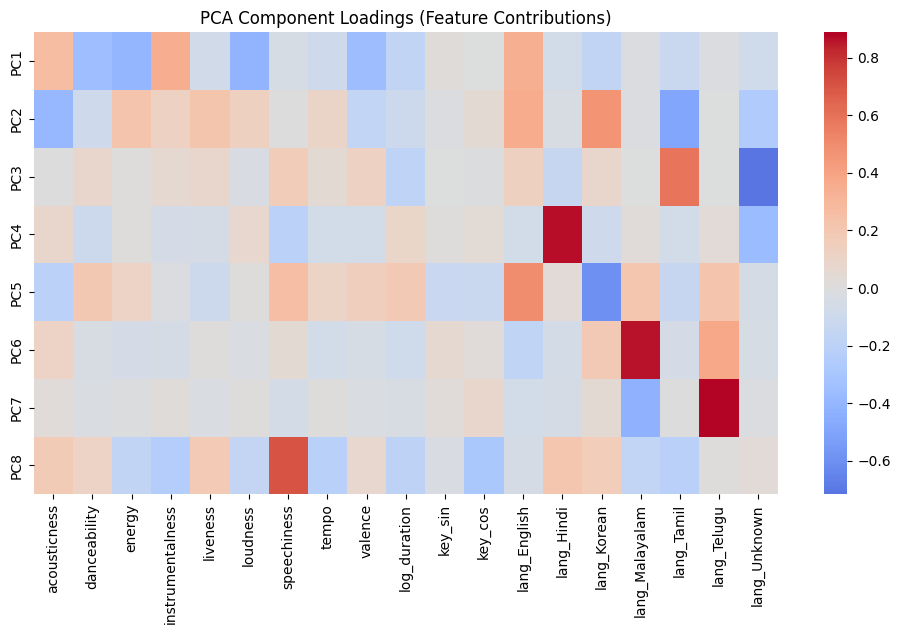

In [60]:
# Component-wise analysis..

loadings = pd.DataFrame(pca.components_, columns=X_df.columns)
plt.figure(figsize=(12, 6))

sns.heatmap(loadings, cmap='coolwarm', center=0, xticklabels=True, yticklabels=[f'PC{i+1}' for i in range(len(loadings))])
plt.title("PCA Component Loadings (Feature Contributions)")
plt.show()


## Clustering

In [62]:

def fit_kmeans(X, n_clusters, metric='euclidean', init='k-medoids++', random_state=42,
               n_init=10, max_iter=300, tol=1e-4, verbose=0):
    
    if metric == 'euclidean':
        kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=random_state,
                        n_init=n_init, max_iter=max_iter, tol=tol, verbose=verbose)
    else:
        # Use KMedoids for other distance metrics (supports 'cosine', 'manhattan', etc.)
        kmeans = KMedoids(n_clusters=n_clusters, metric=metric, init=init, random_state=random_state,
                          max_iter=max_iter)
    
    kmeans.fit(X)
    labels = kmeans.labels_
    
    return kmeans, labels

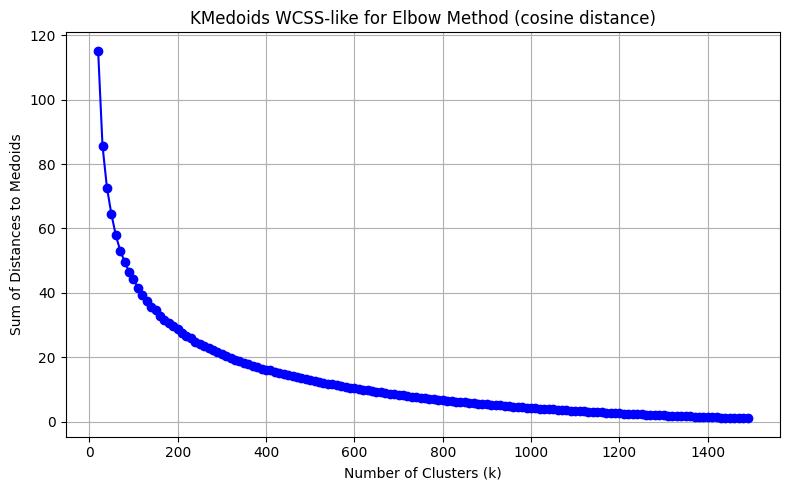

In [65]:
"""Elbow method: Check for appropriate number of clusters"""

# Function to run KMedoids and plot WCSS (Inertia-like for KMedoids)
def plot_kmedoids_wcss(X, k_range=range(20, 1500, 10), metric='cosine', random_state=42):
    wcss = []

    for k in k_range:
        X_sample = resample(X, n_samples=2000, random_state=random_state, replace=True)

        kmedoids = KMedoids(n_clusters=k, metric=metric, random_state=random_state, init="k-medoids++", max_iter=100)
        kmedoids.fit(X_sample)
        labels = kmedoids.labels_
        # Calculate WCSS-like value for KMedoids (sum of distances to medoids)
        wcss_k = 0
        for i in range(k):
            cluster_points_indices = np.where(labels == i)[0]
            if len(cluster_points_indices) > 0:
                cluster_points = X_sample[cluster_points_indices]
                medoid_index = kmedoids.medoid_indices_[i]
                medoid = X_sample[medoid_index] 
                distances = pairwise_distances(cluster_points, [medoid], metric=metric)
                wcss_k += np.sum(distances)
        wcss.append(wcss_k)

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, wcss, marker='o', color='blue')
    plt.title(f'KMedoids WCSS-like for Elbow Method ({metric} distance)')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Sum of Distances to Medoids')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_kmedoids_wcss(X_pca)

In [67]:
kmeans, labels = fit_kmeans(X_pca, metric = "cosine", n_clusters= 150)
kmeans

In [40]:
# Check Clustering Performance
silhouette_score(X_pca, labels)

0.1317822583180099

In [ ]:
# Save the model using pickle...
with open(path + '/clustering_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

In [75]:
# Open the saved weights..
with open(path + '/clustering_model.pkl', 'rb') as f:
    kmeans = pickle.load(f)

labels = kmeans.labels_

## Finding - Nearest Song

In [76]:
def find_closest_songs(song_data_pca, song_data_feat, kmeans, X_pca, X_df, df, n_neighbors=5, metric='cosine'):
    song_cluster = kmeans.predict([song_data_pca])[0]
    
    cluster_mask = kmeans.labels_ == song_cluster
    cluster_indices = np.where(cluster_mask)[0]
    cluster_points = X_df.iloc[cluster_mask].values

    distances = pairwise_distances([song_data_feat], cluster_points, metric=metric).flatten()
    is_self = np.all(np.isclose(cluster_points, song_data_feat), axis=1)
    distances[is_self] = np.inf

    distances_dict = {idx: distance for idx, distance in enumerate(distances)}
    sorted_distances = {k: v for k, v in sorted(distances_dict.items(), key=lambda item: abs(item[1]))}
    closest_in_cluster = list(sorted_distances.keys())[:n_neighbors]
    closest_df_indices = cluster_indices[closest_in_cluster]

    closest_songs_with_distance = [
        f"{df.iloc[i]['track_name']}"        
        for idx, i in enumerate(closest_df_indices)
    ]
    return closest_songs_with_distance


In [77]:
def predict_next_songs(X_df, current_song, n):

    
    song_index = df[df['track_name'] == current_song].index[0]
    song_data_pca = X_pca[song_index]
    song_data_feat = X_df.iloc[song_index]
    
    closest_songs = find_closest_songs(song_data_pca, song_data_feat, kmeans, X_pca, X_df, df, n_neighbors=n, metric='cosine')
    
    return closest_songs


# Recommendation Time!!

In [81]:
print("Which song are you Listening To? \n")


input_box = widgets.Text(
    value='',
    placeholder='Type a song name...',
    description='Enter Song:',
    layout=widgets.Layout(width='320px', margin='0px 0px 10px 0px') 
)

# Suggestions and store button
suggestions_box = widgets.VBox(layout=widgets.Layout(align_items='flex-start'))
store_button = widgets.Button(
    description='Select Song',
    button_style='success',
    layout=widgets.Layout(width='150px', margin='10px 0px 0px 7px')
)


# Output box
output_box = widgets.Output(layout=widgets.Layout(
    border='1px solid gray',
    width='400px',
    height='150px',
    overflow_y='scroll', 
    margin='0px 0px 0px 0px'
))

# Suggestion count input
suggestion_count_input = widgets.BoundedIntText(
    value=5,
    min=1,
    max=20,
    step=1,
    description='Suggestions:',
    layout=widgets.Layout(width='120px', margin='20px 150px 0px 30px')
)

selected_song = None

def on_suggestion_count_change(change):
    if selected_song:
        song_analysis(selected_song)

# Update suggestions based on user input
def update_suggestions(change):
    user_input = change['new'].strip()
    suggestions_box.children = []
    if user_input:
        suggestions = df[df['track_name'].str.contains(user_input, case=False)].head(5)
        buttons = []
        for track in suggestions['track_name']:
            btn = widgets.Button(description=track, layout=widgets.Layout(width='auto'))
            btn.on_click(on_suggestion_click)
            buttons.append(btn)
        suggestions_box.children = buttons

# Handle suggestion click
def on_suggestion_click(button):
    global selected_song
    selected_song = button.description
    input_box.value = selected_song 
    song_analysis(selected_song)


def store_selection(button):
    global selected_song
    if selected_song:
        song_analysis(selected_song)
    else:
        print("No song selected.")

# Predict songs
def song_analysis(song_name):
    with output_box:
        output_box.clear_output()

        
        display(widgets.HTML(
            f"""
            <div style="height:150px; overflow-y:auto;">
                <b>🎶 Current Song:</b> '{song_name}'<br>
                Songs recommended for your vibe:<br>
                {''.join([f"{i+1}. {song} 🎧<br>" for i, song in enumerate(predict_next_songs(X_df, song_name, n=suggestion_count_input.value))])}
            </div>
            """
        ))

# Observers
input_box.observe(update_suggestions, names='value')
suggestion_count_input.observe(on_suggestion_count_change, names='value')
store_button.on_click(store_selection)

# Layouts
left_column = widgets.VBox([input_box, suggestions_box, store_button], layout=widgets.Layout(min_width='350px'))
right_column = widgets.VBox([suggestion_count_input])

main_layout = widgets.HBox(
    [left_column, output_box, right_column],
    layout=widgets.Layout(justify_content='flex-start', align_items='flex-start', gap='40px')
)

# Display
display(main_layout)


Which song are you Listening To? 



In [46]:
"""
Try Songs:

1. Khairiyat
2. Pee Loon
3. Pal Pal Dil ke pass
4. Hawayein
5. Tere rang mein
6. tujhe kitna chahne lage

"""

'\nTry Songs:\n\n1. Khairiyat\n2. Pee Loon\n3. Pal Pal Dil ke pass\n4. Hawayein\n5. Tere rang mein\n\n'